# Notebook 1: Data Loading, Cleaning & Engagement Labels
Run this first. It produces `master_clean.parquet` used by all later notebooks.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Social_Media_Mining_Project'
DATA_DIR  = f'{BASE}/data/'
OUT_DIR   = f'{BASE}/outputs/'
FIG_DIR   = f'{BASE}/figures/'

import os
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
import glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

def set_all_seeds(seed=6):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_all_seeds(6)
pd.set_option('display.max_columns', None)

## 1.1 Load all 50 CSVs

In [ ]:
def load_all_subreddits(data_dir):
    csv_files = [
        f for f in glob.glob(os.path.join(data_dir, '*.csv'))
        if os.path.basename(f) != '50_subreddits_list.csv'
    ]
    print(f'Found {len(csv_files)} CSV files')
    frames = []
    for fpath in sorted(csv_files):
        try:
            tmp = pd.read_csv(fpath, encoding='utf-8-sig', low_memory=False)
            tmp['source_file'] = os.path.basename(fpath)
            frames.append(tmp)
        except Exception as e:
            print(f'  SKIPPED {fpath}: {e}')
    df = pd.concat(frames, ignore_index=True)
    print(f'Total rows: {len(df):,}')
    return df

df_raw = load_all_subreddits(DATA_DIR)
df_raw.head(3)

Found 50 CSV files
Total rows: 49,266


,id,title,score,upvote_ratio,num_comments,created_utc,subreddit,subscribers,permalink,url,domain,num_awards,num_crossposts,crosspost_subreddits,post_type,is_nsfw,is_bot,is_megathread,body,source_file
0,1b9db8z,'Dragon Ball' Creator Akira Toryiyama Has Pass...,64352,0.95,3363,2024-03-08 08:31:22,anime,11104213,https://www.reddit.com/r/anime/comments/1b9db8...,https://x.com/DB_official_en/status/1765935471...,x.com,0,24,NaN,link,False,False,False,NaN,anime.csv
1,jhqdgv,Kaguya-sama: Love Is War - Season 3 announced!,37983,0.98,1235,2020-10-25 14:30:48,anime,11104213,https://www.reddit.com/r/anime/comments/jhqdgv...,https://i.redd.it/7np2w8ngh7v51.png,i.redd.it,0,3,NaN,image,False,False,False,NaN,anime.csv
2,g9lda9,Aqua in yoga pants | Konosuba,31745,0.98,680,2020-04-28 16:45:45,anime,11104213,https://www.reddit.com/r/anime/comments/g9lda9...,https://i.redd.it/5s7s3g2bljv41.png,i.redd.it,0,19,NaN,image,False,False,False,NaN,anime.csv


In [ ]:
print('Shape:', df_raw.shape)
print('\nNulls:')
print(df_raw.isnull().sum())
print('\npost_type:')
print(df_raw['post_type'].value_counts())
print('\nUnique subreddits:', df_raw['subreddit'].nunique())

Shape: (49266, 20)

Nulls:
id                          0
title                       0
score                       0
upvote_ratio                0
num_comments                0
created_utc                 0
subreddit                   0
subscribers                 0
permalink                   0
url                         0
domain                      0
num_awards                  0
num_crossposts              0
crosspost_subreddits    48944
post_type                   0
is_nsfw                     0
is_bot                   4203
is_megathread               0
body                    40789
source_file                 0
dtype: int64

post_type:
post_type
link     20184
image    13885
text     13122
video     2075
Name: count, dtype: int64

Unique subreddits: 50


## 1.2 Clean

In [ ]:
def clean_dataframe(df):
    df = df.copy()

    # Drop all-null / all-zero columns
    cols_to_drop = []
    if 'crosspost_subreddits' in df.columns and df['crosspost_subreddits'].isnull().all():
        cols_to_drop.append('crosspost_subreddits')
    if 'num_awards' in df.columns and (df['num_awards'].fillna(0) == 0).all():
        cols_to_drop.append('num_awards')
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f'Dropped: {cols_to_drop}')

    # Deduplicate on post id
    before = len(df)
    df.drop_duplicates(subset='id', keep='first', inplace=True)
    print(f'Dedup: removed {before - len(df)}, kept {len(df):,}')

    # Parse datetime
    df['created_utc'] = pd.to_datetime(df['created_utc'], utc=True, errors='coerce')

    # Fix booleans
    df['is_bot'] = df['is_bot'].fillna(False).astype(bool)
    df['is_nsfw'] = df['is_nsfw'].fillna(False).astype(bool)
    df['is_megathread'] = df['is_megathread'].fillna(False).astype(bool)

    # Fill body
    df['body'] = df['body'].fillna('')

    # Remove bots
    n_bots = df['is_bot'].sum()
    df = df[~df['is_bot']].copy()
    print(f'Removed {n_bots} bot posts, {len(df):,} remain')

    # Normalize post_type
    df['post_type'] = df['post_type'].str.lower().str.strip()

    df.reset_index(drop=True, inplace=True)
    return df

df_clean = clean_dataframe(df_raw)
print('\nCleaned shape:', df_clean.shape)

Dropped: ['num_awards']
Dedup: removed 0, kept 49,266
Removed 28 bot posts, 49,238 remain

Cleaned shape: (49238, 19)


/tmp/ipykernel_486/3471051960.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_bot'] = df['is_bot'].fillna(False).astype(bool)


## 1.3 Temporal features

In [ ]:
def add_temporal_features(df):
    df = df.copy()
    df['year']        = df['created_utc'].dt.year
    df['month']       = df['created_utc'].dt.month
    df['hour']        = df['created_utc'].dt.hour
    df['day_of_week'] = df['created_utc'].dt.dayofweek  # 0=Mon, 6=Sun
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
    return df

df_clean = add_temporal_features(df_clean)
print('Year range:', df_clean['year'].min(), '-', df_clean['year'].max())
print(df_clean['year'].value_counts().sort_index())

Year range: 2011.0 - 2024.0
year
2011.0        1
2012.0        2
2013.0        5
2014.0      167
2015.0      600
2016.0     1744
2017.0     6254
2018.0     8029
2019.0     8218
2020.0    11033
2021.0     6086
2022.0     3911
2023.0     1580
2024.0      623
Name: count, dtype: int64


## 1.4 Engagement labels

Composite = 0.5 * norm(log1p(score)) + 0.5 * norm(log1p(num_comments))

In [ ]:
def create_engagement_labels(df, viral_percentile=0.80):
    df = df.copy()
    df['log_score']    = np.log1p(df['score'])
    df['log_comments'] = np.log1p(df['num_comments'])

    def minmax(s):
        return (s - s.min()) / (s.max() - s.min() + 1e-9)

    df['norm_score']    = minmax(df['log_score'])
    df['norm_comments'] = minmax(df['log_comments'])
    df['engagement_score'] = 0.5 * df['norm_score'] + 0.5 * df['norm_comments']

    threshold = df['engagement_score'].quantile(viral_percentile)
    df['is_viral'] = (df['engagement_score'] >= threshold).astype(int)

    rho, pval = spearmanr(df['score'], df['num_comments'])
    print(f'Spearman rho (score vs comments): {rho:.4f}  p={pval:.2e}')
    print(f'Viral threshold (p{int(viral_percentile*100)}): {threshold:.4f}')
    print(f'Viral posts: {df["is_viral"].sum():,} / {len(df):,}')
    return df

df = create_engagement_labels(df_clean)
df[['title','score','num_comments','engagement_score','is_viral']].head(8)

Spearman rho (score vs comments): 0.5621  p=0.00e+00
Viral threshold (p80): 0.7025
Viral posts: 9,848 / 49,238


,title,score,num_comments,engagement_score,is_viral
0,'Dragon Ball' Creator Akira Toryiyama Has Pass...,64352,3363,0.701610,0
1,Kaguya-sama: Love Is War - Season 3 announced!,37983,1235,0.612821,0
2,Aqua in yoga pants | Konosuba,31745,680,0.571216,0
3,This is not a Cigarette [Gintama],31131,412,0.547271,0
4,The Devil is a Part-Timer Season 2 Announced!,30752,2463,0.625924,0
5,'Konosuba' Season 3 Announced,30173,1009,0.584548,0
6,So some madlad went ahead and did this...,29847,569,0.558119,0
7,"""Spice and Wolf"" New Anime Announced",29591,1878,0.610612,0


## 1.5 Distribution plots

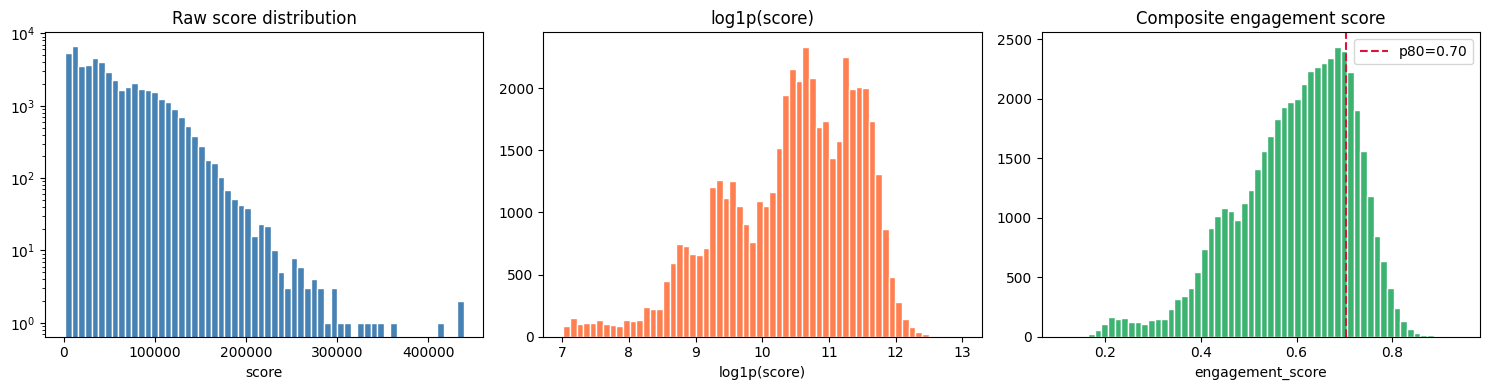

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['score'], bins=60, color='steelblue', edgecolor='white', lw=0.4)
axes[0].set_title('Raw score distribution')
axes[0].set_xlabel('score'); axes[0].set_yscale('log')

axes[1].hist(df['log_score'], bins=60, color='coral', edgecolor='white', lw=0.4)
axes[1].set_title('log1p(score)')
axes[1].set_xlabel('log1p(score)')

axes[2].hist(df['engagement_score'], bins=60, color='mediumseagreen', edgecolor='white', lw=0.4)
t = df['engagement_score'].quantile(0.80)
axes[2].axvline(t, color='crimson', lw=1.5, linestyle='--', label=f'p80={t:.2f}')
axes[2].set_title('Composite engagement score')
axes[2].set_xlabel('engagement_score')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}01_engagement_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 Save master parquet

In [ ]:
out_path = f'{OUT_DIR}master_clean.parquet'
df.to_parquet(out_path, index=False)
print(f'Saved -> {out_path}')
print('Final shape:', df.shape)
print('Columns:', list(df.columns))

Saved -> /content/drive/MyDrive/Social_Media_Mining_Project/outputs/master_clean.parquet
Final shape: (49238, 30)
Columns: ['id', 'title', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'subreddit', 'subscribers', 'permalink', 'url', 'domain', 'num_crossposts', 'crosspost_subreddits', 'post_type', 'is_nsfw', 'is_bot', 'is_megathread', 'body', 'source_file', 'year', 'month', 'hour', 'day_of_week', 'is_weekend', 'log_score', 'log_comments', 'norm_score', 'norm_comments', 'engagement_score', 'is_viral']
